### Error Analysis EmoDB

In [1]:
import pandas as pd

pred_files = {
    "predictions_distilhubert" : r"C:\path\to\test_predictions_distilhubert_cv.csv",  
    "predictions_hubert_b": r"C:\path\to\test_predictions_hubertxl_cv.csv", 
    "predictions_wav2vec_b" : r"C:\path\to\test_predictions_wav2vec_b_cv.csv", 
    "predictions_wav2vec_l" : r"C:\path\to\test_predictions_wav2vec_l_cv.csv", 
    "predictions_wavlm_b" : r"C:\path\to\test_predictions_wavlm_b_cv.csv",
    "predictions_wavlm_l" : r"C:\path\to\test_predictions_wavlm_l_cv.csv" }

female_speakers = [8,9,13,14,16]
male_speakers= [3,10,11,12,15]


def get_gender(speaker_id): 
    if speaker_id in female_speakers: 
        return "female"
    elif speaker_id in male_speakers:
        return "male"
    else:
        return "unclear gender"

def analysed_wrong_preds(csv_path): 
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    wrong_df = df[df["correct"] == False]
    wrong_by_gender = wrong_df["gender"].value_counts()

    male_total = total_by_gender.get("male", 0)
    female_total = total_by_gender.get("female", 0)
    male_wrong = wrong_by_gender.get("male", 0)
    female_wrong = wrong_by_gender.get("female", 0)


    return{
        "total_wrong" : len(wrong_df),
        "male_total" : male_total,
        "male_wrong": male_wrong,
        "female_total": female_total,
        "female_wrong": female_wrong,
        "male_error_rate_perc": round(male_wrong/male_total * 100, 2) if male_total else None,
        "female_error_rate_perc": round(female_wrong/female_total * 100, 2) if female_total else None
    }

#### Getting a basic idea about the test set size and how many samples per emotion it includes 

In [2]:
test_sample_path = pred_files["predictions_distilhubert"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        26
boredom      16
disgust       9
fear         14
happiness    15
neutral      15
sadness      12
Name: count, dtype: int64
Total number of samples 107


In [22]:
test_sample_path = pred_files["predictions_hubert_b"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        26
boredom      16
disgust       9
fear         14
happiness    15
neutral      15
sadness      12
Name: count, dtype: int64
Total number of samples 107


In [23]:
test_sample_path = pred_files["predictions_hubert_xl"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        25
boredom      17
disgust       9
fear         13
happiness    14
neutral      16
sadness      13
Name: count, dtype: int64
Total number of samples 107


In [24]:
test_sample_path = pred_files["predictions_wav2vec_b"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        26
boredom      16
disgust       9
fear         14
happiness    15
neutral      15
sadness      12
Name: count, dtype: int64
Total number of samples 107


In [25]:
test_sample_path = pred_files["predictions_wav2vec_l"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        25
boredom      16
disgust       9
fear         14
happiness    14
neutral      16
sadness      13
Name: count, dtype: int64
Total number of samples 107


In [26]:
test_sample_path = pred_files["predictions_wavlm_b"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        26
boredom      16
disgust       9
fear         14
happiness    15
neutral      15
sadness      12
Name: count, dtype: int64
Total number of samples 107


In [27]:
test_sample_path = pred_files["predictions_wavlm_l"]
df = pd.read_csv(test_sample_path, sep= None, engine= "python")

emo_counts = df["ground_truth"].value_counts().sort_index()
print("Number of Emotion Samples in Test Set")
print(emo_counts)
print(f"Total number of samples {len(df)}")

Number of Emotion Samples in Test Set
ground_truth
anger        26
boredom      16
disgust       9
fear         14
happiness    15
neutral      15
sadness      12
Name: count, dtype: int64
Total number of samples 107


>> Note: 5/7 models use the predictions of the same fold, namely fold0. Wav2Vec Large and Hubert XL use different fold predictions, however the number of total test samples is identical AND the number of emotion samples only varies across anger and happiness (-1 sample each compared to fold0) and for HubertXL also in fear (-1 compared to fold0), which are then to be found for both in neutral and sadness (+1 each compared to fold0) and for Hubert XL as well in boredom (+1 sample compared to fold0). The selected folds are always the ones where the model performed best

### Checking if the gender imbalance of the EmoDB dataset impacted overall model misclassifications

In [3]:
results = {}
for model_name, path in pred_files.items():
    results[model_name] = analysed_wrong_preds(path)

summary_df = pd.DataFrame(results).T
print(summary_df)

                          total_wrong  male_total  male_wrong  female_total  \
predictions_distilhubert         11.0        50.0         6.0          57.0   
predictions_hubert_b              2.0        50.0         0.0          57.0   
predictions_hubert_xl             4.0        43.0         2.0          64.0   
predictions_wav2vec_b             3.0        50.0         1.0          57.0   
predictions_wav2vec_l             8.0        45.0         4.0          62.0   
predictions_wavlm_b               4.0        50.0         2.0          57.0   
predictions_wavlm_l               1.0        50.0         1.0          57.0   

                          female_wrong  male_error_rate_perc  \
predictions_distilhubert           5.0                 12.00   
predictions_hubert_b               2.0                  0.00   
predictions_hubert_xl              2.0                  4.65   
predictions_wav2vec_b              2.0                  2.00   
predictions_wav2vec_l              4.0         

>> Findings:
>> For most of the models, the error rate is negligible between male and female audio files of the test set (~2%), with a slight exception of Hubert_b (3.51% difference) Distilhubert (3.23% difference in error rate) but these too do not suggest any gender bias.

In [4]:
def print_false_female_files(csv_path):
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    false_female_df = df[(df["correct"] == False) & (df["gender"] == "female")]
    print(f"{len(false_female_df)} false female files")

    grouped = false_female_df.groupby("speaker_id")["audio_file"].apply(list)

    for speaker_id, files in grouped.items():
        print(f"Speaker {speaker_id} ({len(files)} files): {files}")

    return false_female_df

for model_name, path in pred_files.items():
    print(f"\n *** {model_name} ***")
    print_false_female_files(path)


 *** predictions_distilhubert ***
5 false female files
Speaker 9 (2 files): ['09a02Eb.wav', '09a07Wd.wav']
Speaker 14 (1 files): ['14b02Wd.wav']
Speaker 16 (2 files): ['16a07Nb.wav', '16b09Fb.wav']

 *** predictions_hubert_b ***
2 false female files
Speaker 16 (2 files): ['16a07Nb.wav', '16b09Fb.wav']

 *** predictions_hubert_xl ***
2 false female files
Speaker 13 (1 files): ['13a01Wb.wav']
Speaker 16 (1 files): ['16b03Nb.wav']

 *** predictions_wav2vec_b ***
2 false female files
Speaker 13 (1 files): ['13a05Wa.wav']
Speaker 16 (1 files): ['16a07Nb.wav']

 *** predictions_wav2vec_l ***
4 false female files
Speaker 8 (1 files): ['08a01Fd.wav']
Speaker 13 (2 files): ['13b03Fd.wav', '13b10La.wav']
Speaker 14 (1 files): ['14a05Fb.wav']

 *** predictions_wavlm_b ***
2 false female files
Speaker 16 (2 files): ['16a07Nb.wav', '16b09Fb.wav']

 *** predictions_wavlm_l ***
0 false female files


>> Findings:
>> The dominating misclassified recordings of female speakers are of speaker 16 since other than wav_lm_l and wav2vec large, all models misclassified at least one of her recording. Other than that recordings of speaker 14 and 13 were misclassified by two models , with recordings differing though across models.

In [5]:
def print_false_male_files(csv_path):
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)
    total_by_gender = df["gender"].value_counts()

    false_male_df = df[(df["correct"] == False) & (df["gender"] == "male")]
    print(f"{len(false_male_df)} false male files")

    grouped = false_male_df.groupby("speaker_id")["audio_file"].apply(list)

    for speaker_id, files in grouped.items():
        print(f"Speaker {speaker_id} ({len(files)} files): {files}")

    return false_male_df

for model_name, path in pred_files.items():
    print(f"\n *** {model_name} ***")
    print_false_male_files(path)


 *** predictions_distilhubert ***
6 false male files
Speaker 3 (1 files): ['03b01Fa.wav']
Speaker 10 (1 files): ['10a04Nb.wav']
Speaker 11 (3 files): ['11a07Ac.wav', '11b03Wb.wav', '11b09Ad.wav']
Speaker 15 (1 files): ['15b01Wc.wav']

 *** predictions_hubert_b ***
0 false male files

 *** predictions_hubert_xl ***
2 false male files
Speaker 3 (1 files): ['03b02Tb.wav']
Speaker 12 (1 files): ['12b10Ac.wav']

 *** predictions_wav2vec_b ***
1 false male files
Speaker 11 (1 files): ['11a02Ec.wav']

 *** predictions_wav2vec_l ***
4 false male files
Speaker 10 (2 files): ['10a04Wa.wav', '10b01Aa.wav']
Speaker 11 (2 files): ['11a05Lc.wav', '11b10Ld.wav']

 *** predictions_wavlm_b ***
2 false male files
Speaker 3 (1 files): ['03b01Fa.wav']
Speaker 11 (1 files): ['11a07Ac.wav']

 *** predictions_wavlm_l ***
1 false male files
Speaker 3 (1 files): ['03a05Aa.wav']


>> Findings:
>> Speaker 3 is misclassified by 4 models, with the misclassified file being identical for walm_b and distilhubert.
>> Similarly, Speaker 11 is misclssified by 4 models, with the misclassified file being identical for walm_b and distilhubert.
>> Speaker 10 was misclassified by 2 models but the files differ. 

### Getting an idea of whether noise played a role in the misclassifications

In [6]:
from scipy.io import wavfile

def sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02):  
    if len(audio_data.shape) > 1:   #making sure not only mono but also stereo can be handled
        audio_data = np.mean(audio_data, axis=1)

    audio_data = audio_data.astype(np.float64)
    frame_size= int(frame_duration*sample_rate)
    frame_number = len(audio_data) // frame_size

    sound_intensity_frame = [np.var(audio_data[i*frame_size : (i+1)*frame_size]) for i in range(frame_number)]
    sound_intensity_frame = np.array(sound_intensity_frame)

    noise_intensity = np.percentile(sound_intensity_frame, 15)
    speech_intensity = np.percentile(sound_intensity_frame, 50)

    if noise_intensity == 0: 
        noise_intensity = 1e-10  #to avoid zero devision

    #formula: SNR(dB) = 10*log10(signal power/noise power)
    snr_db = 10*np.log10(speech_intensity/noise_intensity)

    is_noisy = snr_db < snr_treshold

    return round(snr_db,2), is_noisy  

In [7]:
import numpy as np
import os
import pandas as pd

os.chdir(r"C:\Users\emodb\emodb\wav")

wav_files = [f for f in os.listdir(".") if f.endswith(".wav")]

total_files = len(wav_files)
clean_files = []
noisy_files = []

for filename in wav_files: 
    try: 
        sample_rate, audio_data = wavfile.read(filename)
        snr_db, is_noisy = sound_noise_ratio(audio_data, sample_rate, snr_treshold= 20.0, frame_duration=0.02)
        if is_noisy: 
            noisy_files.append((filename, snr_db))
        else: 
            clean_files.append((filename, snr_db))
    except Exception as e: 
        print(f"{filename} could not be read due to {e}")

noisy_file_count = len(noisy_files)
clean_file_count = len(clean_files)

noisy_perc = (noisy_file_count / total_files) * 100
print(f"Noisy files found: {noisy_file_count} ({noisy_perc:.2f}%)")

clean_snr_values = [x[1] for x in clean_files] #added only after discovery that mean snr of clean_files only 24.88dB
mean_snr = round(np.mean(clean_snr_values), 2)
if noisy_file_count == 0: 
    print(f"Average SNR of all wav files: {mean_snr} (in dB)")
else: 
    print(f"Average SNR of the clean wav files: {mean_snr} (in dB)")

all_files_data = clean_files + noisy_files
snr_df = pd.DataFrame(all_files_data, columns=["audio_file", "snr_db"])
snr_df["status"] = snr_df["snr_db"].apply(lambda x: "Noisy" if x<20.0 else "Clean")

snr_df.to_csv("snr_results_emodb.csv", index=False)
print("Data saved successfully")

Noisy files found: 299 (55.89%)
Average SNR of the clean wav files: 24.88 (in dB)
Data saved successfully


### Creating a comprehensive overview of 
- which emotion pairs were confused (and how many)
- which speakers were involved (and their gender) as well as how many 
- the SNR of the files that were confused vs correctly classified (for now only an approximation (mean))
  -> to get a rough idea of whether noise could have potentially played a role in the misclassification or not, this is determined by the gap between mean SNR of the confused files and the mean SNR of the correctly classified files
>> - a negative snr gap (resulting from mean_snr_confused < mean_snr_correct) suggestes that noise could have caused the misclassification, while a positive one suggests a speaker specific misclassification
>> -  to keep in mind as well: unless we have a positive snr gap, we should do a detailed check afterwards whether noise really is the issue for misclassification given the small sample size of the emotions in the test set (between 9-26 samples) as it might mislead us. Hence, the size of a negative snr gap might also only become valuable as an indicator for noise severity once the detailed analysis has confirmed noise to be the misclassification cause
>> -  how to interpret the (negative) snr gap size according to [Leduc, 2018](https://www.acousti-tech.com/en/blog/detail/sound-level-and-auditory-perception-4129):  
>>    1 to 2 dB the noise is not perceptible  
>>    3 dB the noise is barely perceptible  
>>    5 dB the presence of the noise in the file is clearly audible  
>>    10 dB the noise sensation is doubled  
>>    20 dB the noise sensation is quadrupled  

In [8]:
import pandas as pd
import numpy as np
true_col = "ground_truth"
pred_col = "predicted"

snr_df = pd.read_csv(r"C:\Users\ASR\Speech Emotion Recognition\EmoDB Dataset\snr_results_emodb.csv")
def load_preds(csv_path, snr_df): 
    df = pd.read_csv(csv_path, sep= None, engine= "python")
    if df["correct"].dtype == object: 
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)

    if snr_df is not None: 
        cols_to_merge = [c for c in ["audio_file", "snr_db"] if c in snr_df.columns]
        if "audio_file" in cols_to_merge: 
            df = df.merge(snr_df[cols_to_merge], on="audio_file", how="left")
    return df

def confusion_pairs_w_context(csv_path, snr_df, model_name, min_count=1):
    df = load_preds(csv_path, snr_df)

    missing = df["snr_db"].isna().sum()
    if missing: 
        print(f"{model_name} is missing {missing} files in the SNR match")

    true_totals = df[true_col].value_counts()

    wrong_df = df[df["correct"] == False].copy()

    wrong_files_df = wrong_df[["audio_file", "snr_db", true_col, pred_col, "speaker_id", "gender"]].copy()
    wrong_files_df.rename(columns={"snr_db": "snr"}, inplace = True)
    
    pair_counts = wrong_df.groupby([true_col, pred_col]).size().reset_index(name = "count")
    pair_counts = pair_counts[pair_counts["count"] >= min_count].sort_values("count", ascending= False)

    rows = []
    for _, row in pair_counts.iterrows(): 
        true_label, pred_label, count = row[true_col], row[pred_col], row["count"]

        subset = wrong_df[(wrong_df[true_col] == true_label) & (wrong_df[pred_col] == pred_label)]
        speakers_involved = subset["speaker_id"].value_counts().to_dict()

        speaker_genders = subset.drop_duplicates("speaker_id").set_index("speaker_id")["gender"].to_dict()
        male_speakers = sorted([id for id, gender in speaker_genders.items() if gender == "male"])
        female_speakers = sorted([id for id, gender in speaker_genders.items() if gender == "female"])


        
        correct_same_class = df[(df[true_col] == true_label) & (df["correct"])]

        rows.append({
            "true": true_label, 
            "predicted": pred_label, 
            "Number_of_Errors": count, 
            "Perc_of_Emotion_Class_in_test": round(count/true_totals.get(true_label, np.nan) * 100, 2),
            "Speakers_involved": len(speakers_involved), 
            "Male_Speakers": male_speakers,
            "Female_Speakers": female_speakers, 
            "mean_snr_confused": round(subset["snr_db"].mean(), 2) if subset["snr_db"].notna().any() else None, 
            "mean_snr_correct":  round(correct_same_class["snr_db"].mean(), 2) if correct_same_class["snr_db"].notna().any() else None
        })

    result_df = pd.DataFrame(rows)
    if not result_df.empty: 
        result_df["snr_gap"] = result_df["mean_snr_confused"] - result_df["mean_snr_correct"]

    print(f"\n ** {model_name} **")
    if not result_df.empty: 
        print(result_df.to_string(index=False, col_space = 15))

    return result_df, wrong_files_df


all_results = {}
all_wrong_files = {}

for model_name, path in pred_files.items():
    summary_df, wrong_files_df = confusion_pairs_w_context(path, snr_df, model_name)
    all_results[model_name] = summary_df
    all_wrong_files[model_name] = wrong_files_df



 ** predictions_distilhubert **
           true       predicted  Number_of_Errors  Perc_of_Emotion_Class_in_test  Speakers_involved   Male_Speakers Female_Speakers  mean_snr_confused  mean_snr_correct         snr_gap
          anger       happiness                 4                          15.38                  4        [11, 15]         [9, 14]              19.23             21.29           -2.06
        neutral         boredom                 2                          13.33                  2            [10]            [16]              17.64             20.31           -2.67
        disgust       happiness                 1                          11.11                  1              []             [9]              22.48             25.35           -2.87
           fear       happiness                 1                           7.14                  1            [11]              []              17.00             20.80           -3.80
           fear         neutral           

**Findings** (which do we consider here? emotions whose misclassification-percentage is high regarding the number of audio files of the emotion in the test set and/or confusion pairs that appear across models -- regardless how often given it reveals a pattern); true -> predicted
- Other than WavLM large, all models have issues with tellling apart ***happiness from anger***
>> anger -> happiness: distilhubert (speaker 11,15 -male; speaker 9,14-fem), hubert_xl(speaker 13, fem) and wav2vec_base (speaker 13, fem);  the recordings of speaker 13 that they misclassified differed though;
>> >> happiness -> anger: was confused by wavlm_b(speaker 16, fem) , wav2veclarge(speaker 14, fem), hubert_base (speaker 16, fem), distilhubert(speaker 16, fem); those who misclassified a file of speaker 16 all misclassified the same recording; only recordings of female speakers were misclassified

- ->  ***happiness and fear***

>> happiness->fear: distilhubert(speaker 3, male), wav2vec_l (speaker 8,13 - fem), wavlm_base(speaker 3, male); the misclassified file of speaker 3 is identical across models;
>> >> fear -> happiness: distilhubert (speaker 11, male), hubert_xl (speaker 12, male), wavlm_l(speaker 3, male); all misclassified files were of male speakers

-> ***happiness and disgust***
>> disgust -> happiness: distilhubert(speaker 9, fem) & wav2vec_base(speaker 11,male)
>> >> happiness -> disgust: none 

-> ***neutral & boredom***
>> neutral -> boredom: all models except wavlm_l & wav2vec_l; distilhubert(speaker 10, male; speaker 16-fem); hubert_b(speaker 16,fem); hubertxl(speaker 16,fem); wav2vec_b(speaker 16,fem), wav_lm_b(speaker 16,fem);
>> with the exception of hubertxl, all misclassified the same recoridng of speaker 16 (16a07Nb);
>> >> boredom -> neutral: only misclassified by wav2veclarge (speaker 13,fem)

## Creating a Visualisation of the relevant misclassified emotion pairs and the models that got them wrong

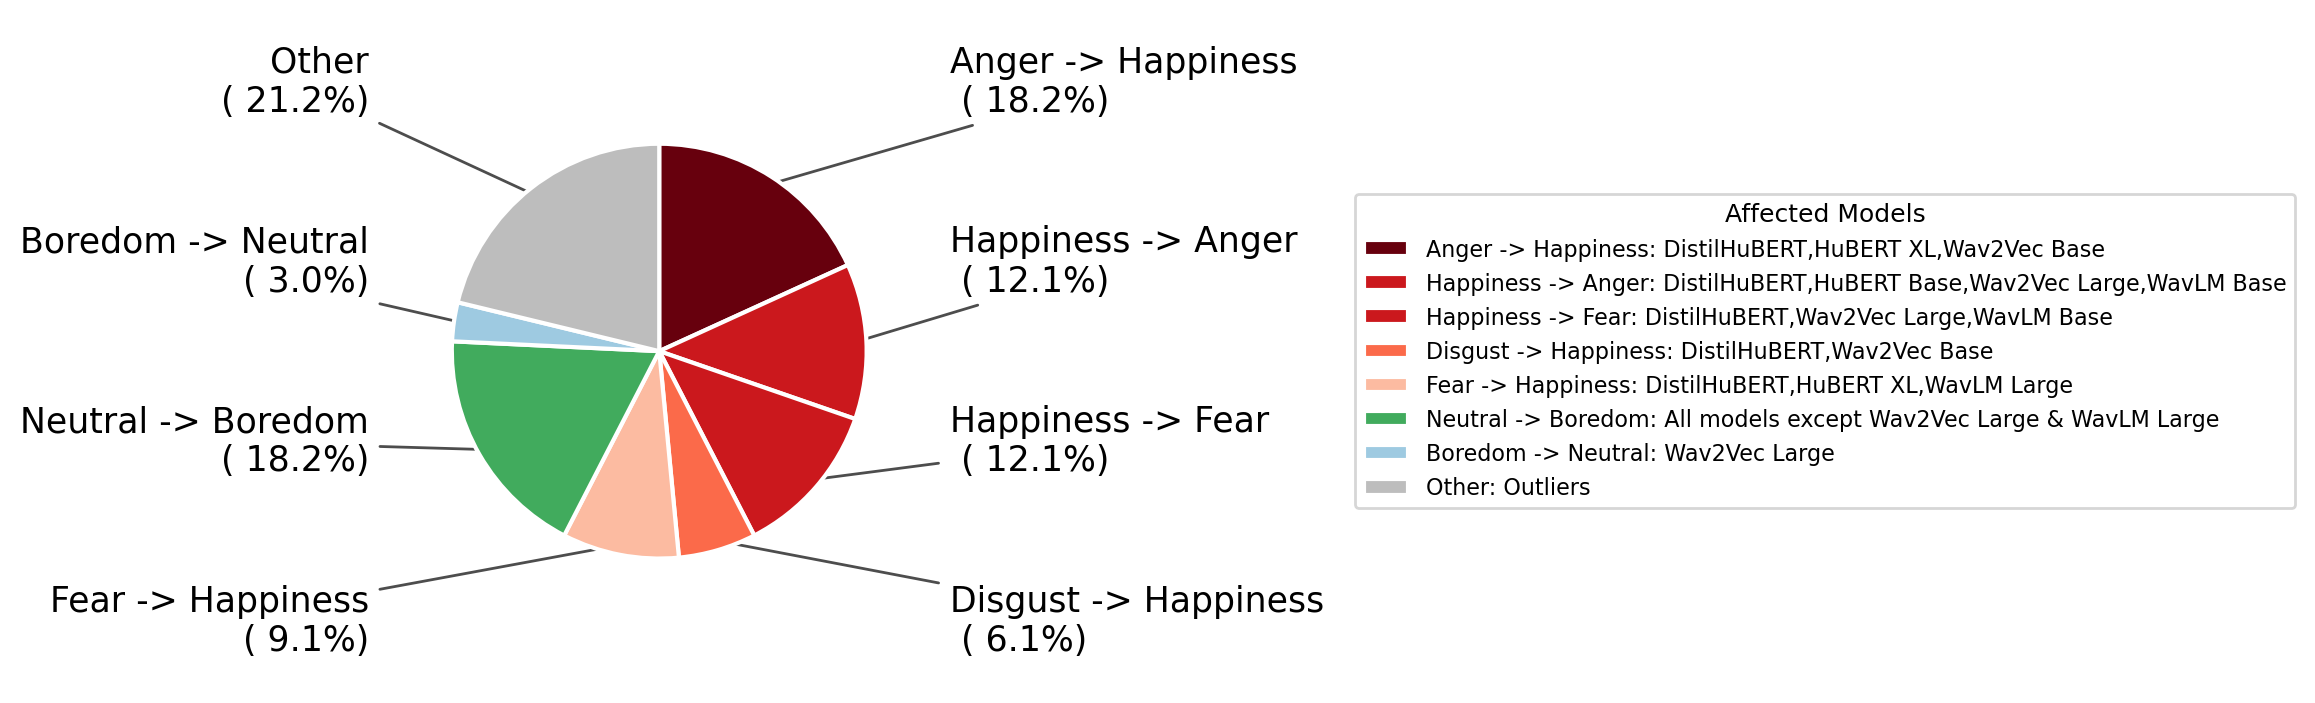

In [29]:
import matplotlib.cm as cm 
import matplotlib.pyplot as plt 

emo_pair_counts = {
    ("Happiness", "Anger") : {"count": 4, "models": ["DistilHuBERT", "HuBERT Base", "Wav2Vec Large", "WavLM Base" ]},
    ("Anger", "Happiness") : {"count": 6, "models": ["DistilHuBERT", "HuBERT XL", "Wav2Vec Base" ]},
    ("Happiness", "Fear") : {"count": 4, "models": ["DistilHuBERT", "Wav2Vec Large", "WavLM Base" ]},
    ("Fear", "Happiness") : {"count": 3, "models": ["DistilHuBERT", "HuBERT XL", "WavLM Large"]},
    ("Disgust", "Happiness") : {"count": 2, "models": ["DistilHuBERT", "Wav2Vec Base"]},
    ("Boredom", "Neutral") : {"count": 1, "models": ["Wav2Vec Large"]},
    ("Neutral", "Boredom") : {"count": 6, "models": ["All models except Wav2Vec Large & WavLM Large"]},
    ("Other", "Other"): {"count": 7, "models": ["Outliers"]},
}

total_errors = 33

emo_colour =  {
    "Anger" : "#67000d",   #highest arousal = darkest shade of red
    "Happiness": "#cb181d", 
    "Disgust": "#fb6a4a",
    "Fear": "#fcbba1", 
    "Neutral": "#41ab5d", #green 
    "Boredom": "#9ecae1", # light blue for it being a low arousal emotion 
    "Other": "#bdbdbd"
}

emo_order = ["Anger", "Happiness", "Disgust", "Fear", "Neutral", "Boredom", "Other" ]
pairs = sorted(emo_pair_counts.keys(), key = lambda k: (emo_order.index(k[0]), -emo_pair_counts[k]["count"]))
counts = [emo_pair_counts[p]["count"] for p in pairs]
models_per_pair = [emo_pair_counts[p]["models"] for p in pairs]
colours = [emo_colour[true] for (true, _) in pairs]
labels = ["Other" if t == "Other"  else f"{t} -> {p}" for (t,p) in pairs]
emotion_pair_errors = sum(counts)

fig, ax = plt.subplots(figsize= (12,9), dpi=200)
wedges, _ = ax.pie(counts, colors=colours, startangle=90, counterclock=False, wedgeprops=dict(edgecolor="white", linewidth=1.5))

angles = [(w.theta2 - w.theta1) / 2 + w.theta1 for w in wedges]
xs = [np.cos(np.deg2rad(a)) for a in angles]
ys = [np.sin(np.deg2rad(a)) for a in angles]
right_index = [i for i in range(len(wedges)) if xs[i] >= 0]
left_index = [i for i in range(len(wedges)) if xs[i] < 0]
right_index.sort(key=lambda i: -ys[i])
left_index.sort(key=lambda i: -ys[i])

label_ytext = {}
for index_group in (right_index, left_index):
    n = len(index_group)
    if n == 0: 
        continue
    y_pos = np.linspace(1.3, -1.3, n) if n> 1 else [0.0]
    for i, index in enumerate(index_group): 
        label_ytext[index] = y_pos[i]
        

keywords = dict(arrowprops=dict(arrowstyle="-", color="0.3", lw=1), zorder=0, va="center")
for i, wedge in enumerate(wedges): 
    x, y = xs[i], ys[i]
    horizontalalignment = "left" if x>= 0 else "right"
    #connectionstyle = f"angle, angleA=0, angleB={angles[i]}"
    keywords["arrowprops"]["connectionstyle"] = "arc3,rad=0"
    perc = counts[i] / total_errors *100

    x_text = 1.4 * np.sign(x) if x !=0 else 1.4
    y_text = label_ytext[i]
    
    ax.annotate(f"{labels[i]}\n ({perc: .1f}%)", xy=(x* 0.95, y*0.95), xytext=(x_text, y_text), horizontalalignment = horizontalalignment, fontsize=12.5, **keywords)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-1.6, 1.6)

#ax.set_title("Emotion Confusion Pairs", fontsize=11, pad=30)
legend_labels = [f"{labels[i]}: {",".join(models_per_pair[i]) or "N/A"}" for i in range(len(pairs))]
ax.legend(wedges, legend_labels, title="Affected Models", loc="center left", bbox_to_anchor=(1.25, 0, 0.5, 1), fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\ASR\Speech Emotion Recognition\EmoDB Dataset\Misclassified Emotion Pairs_cv.png", bbox_inches = "tight")
plt.show()
             


For identifying the order of emotions by high-low arousal:   
https://www.researchgate.net/figure/Emotions-in-valence-arousal-space-13_fig3_329718637    
https://www.researchgate.net/figure/Visualization-of-emotion-classification-a-High-Arousal-HA-and-Low-Arousal-LA_fig1_397725290

## Visualising the SNR of all files in the test set and the misclassified files among them 

<Figure size 640x480 with 0 Axes>

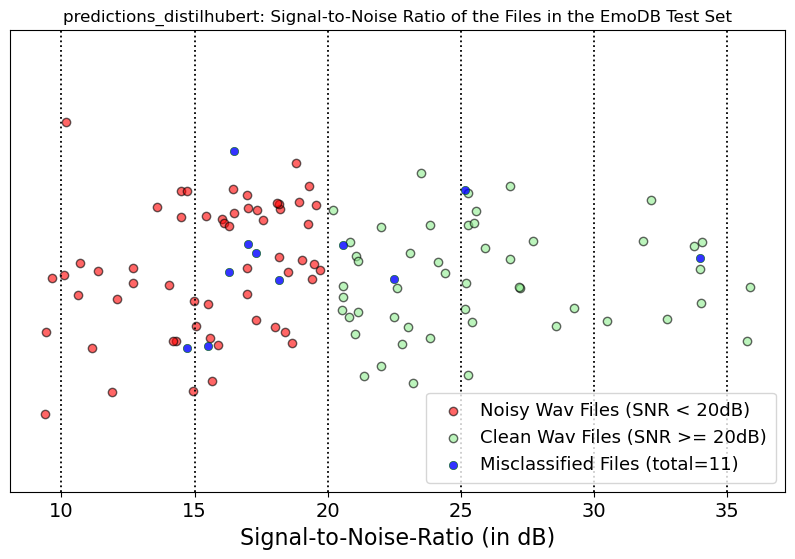

<Figure size 640x480 with 0 Axes>

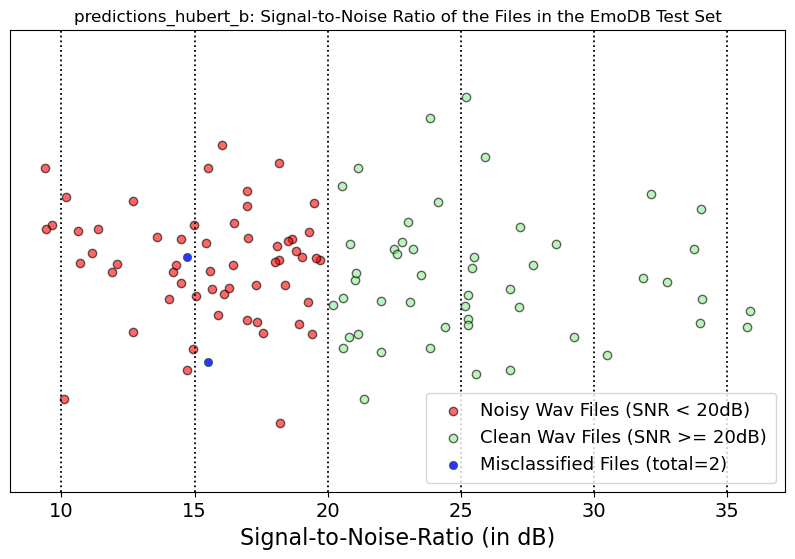

<Figure size 640x480 with 0 Axes>

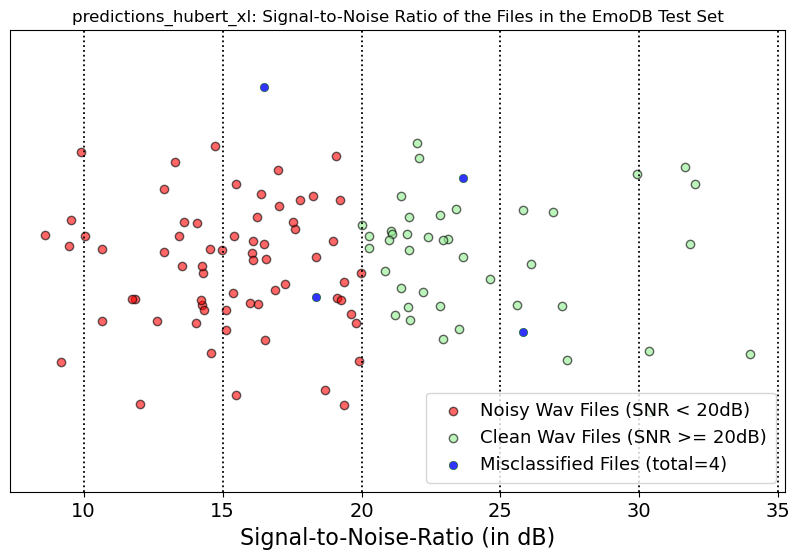

<Figure size 640x480 with 0 Axes>

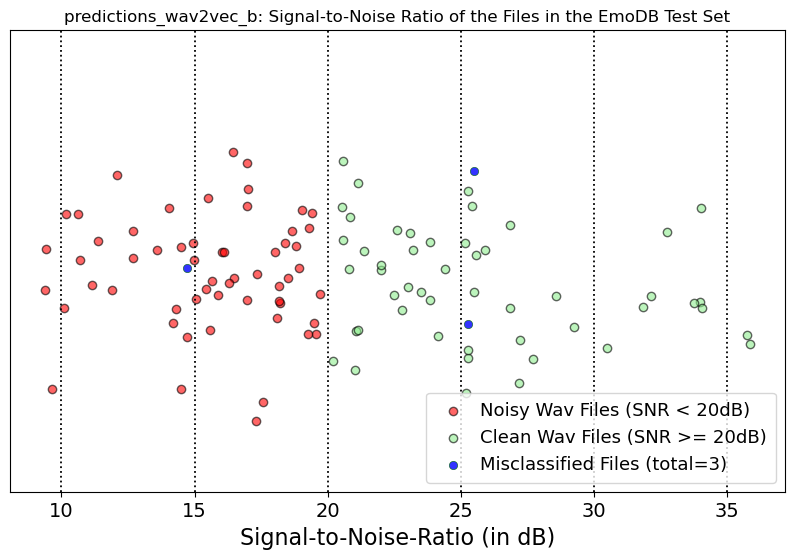

<Figure size 640x480 with 0 Axes>

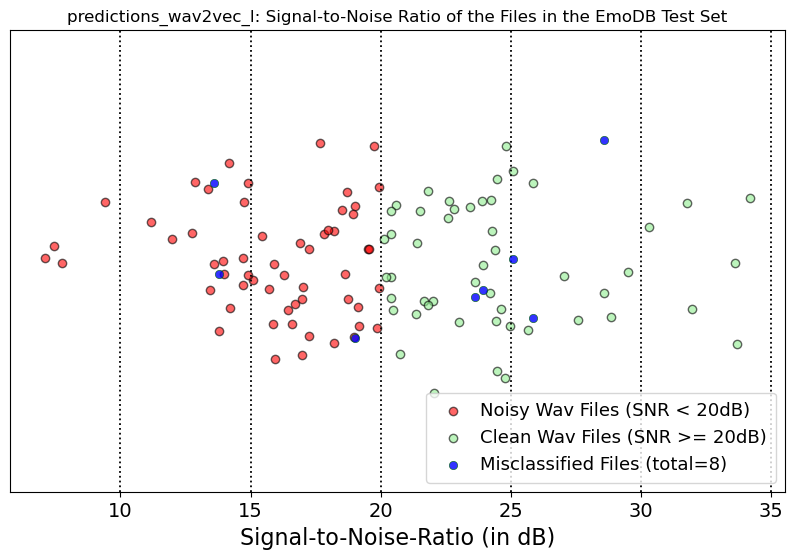

<Figure size 640x480 with 0 Axes>

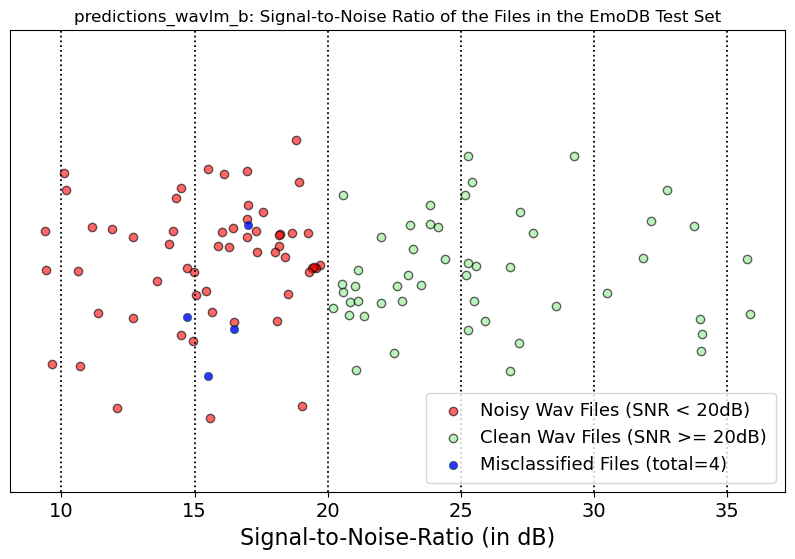

<Figure size 640x480 with 0 Axes>

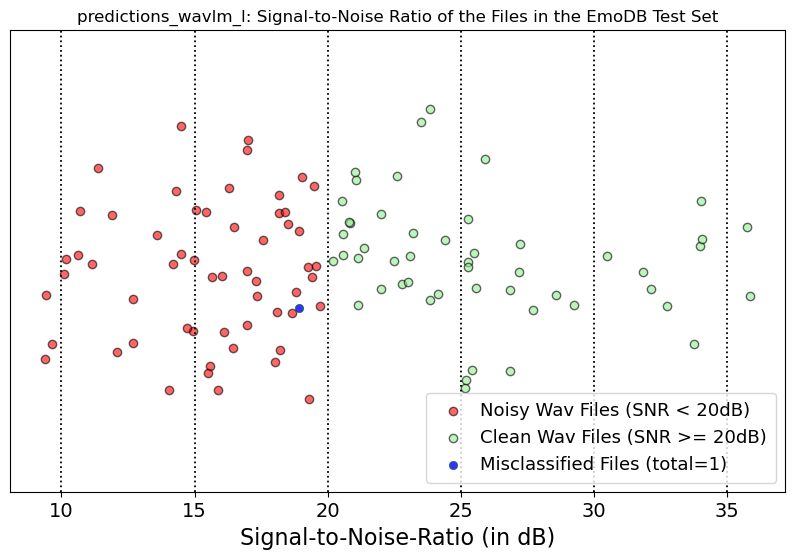

In [14]:
import matplotlib.pyplot as plt

for model_name, path in pred_files.items():
    plt.clf()

    test_df = pd.read_csv(path, sep=None, engine="python")
    test_filenames = set(test_df["audio_file"])

    noisy_test = [x for x in noisy_files if x[0] in test_filenames]
    noisy_snr_values = [x[1] for x in noisy_test]
    ynoisy = np.random.normal(0, 0.04, size= len(noisy_snr_values))
    
    clean_test = [x for x in clean_files if x[0] in test_filenames]
    clean_snr_values = [x[1] for x in clean_test]
    yclean= np.random.normal(0, 0.04, size=len(clean_snr_values))

    df = all_wrong_files[model_name]
    wrong_snr_values = df["snr"].dropna().tolist()
    ywrong = np.random.normal(0, 0.04, size=len(wrong_snr_values))
    
    plt.figure(figsize=(10,6))
    plt.scatter(noisy_snr_values, ynoisy, color="r", label="Noisy Wav Files (SNR < 20dB)", alpha=0.6, edgecolors="k")
    plt.scatter(clean_snr_values, yclean, color="lightgreen", label="Clean Wav Files (SNR >= 20dB)", alpha=0.6, edgecolors="k")

    if wrong_snr_values: 
        plt.scatter(wrong_snr_values, ywrong, color = "b", edgecolors="darkgreen", label= f"Misclassified Files (total={len(wrong_snr_values)})", alpha=0.8, linewidth=0.5, zorder=5)
    plt.xlabel("Signal-to-Noise-Ratio (in dB)", fontsize=16)
    plt.xticks(fontsize=14)

    plt.title(f"{model_name}: Signal-to-Noise Ratio of the Files in the EmoDB Test Set")
    plt.legend(loc="lower right", fontsize=13, markerscale=1.0, handletextpad=0.5, borderpad=0.5, framealpha=0.8)
    plt.ylim(0.15, -0.16)
    plt.grid(axis="x", ls=":", color= "k", linewidth= 1.3, zorder=0)

    plt.gca().axes.get_yaxis().set_visible(False)


    plt.show()
    #plt.save(savefig)

>> Finding: 
For both WavLM models as well as Hubert_b, all files that were misclassified were noisy files. However, noise being the reason they got misclassified seems rather unlikely, considering that for all those models, there has been minimum one sound file with a lower SNR than the lowest SNR of the misclassified file, which was classified correctly. This gives us a first hint that noise does not play as big of a role here as it might initially seem. 

### Defining a function that calculates Pearson's r

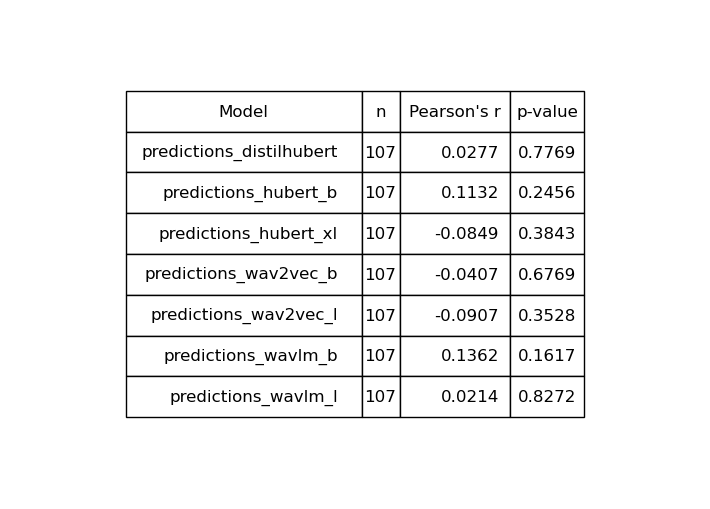

In [16]:
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt

def compute_pearsonr_w_snr(csv_path, snr_df, model_name): 
    df = load_preds(csv_path, snr_df)
    
    missing = df["snr_db"].isna().sum()
    if missing: 
        print(f"{model_name} is missing {missing} files in the SNR match")

    clean_df = df.dropna(subset=["snr_db", "correct"]).copy()
    clean_df["correct"] = clean_df["correct"].astype(int)

    x = clean_df["snr_db"].values
    y = clean_df["correct"].values

    pcc, p_value = pearsonr(x,y)

    n=len(clean_df)

    return {"Model": model_name, "n": n, "Pearson's r": pcc, "p-value": p_value}

if __name__=="__main__": 
    correlation_results = {}
    for model_name, csv_path in pred_files.items(): 
        correlation_results[model_name] = compute_pearsonr_w_snr(csv_path, snr_df, model_name)

    correlation_df = pd.DataFrame(correlation_results.values())
    correlation_df["Pearson's r"] = correlation_df["Pearson's r"].round(4)
    correlation_df["p-value"] = correlation_df["p-value"].round(4)

    n_rows, n_cols = correlation_df.shape
    
    fig, ax = plt.subplots(figsize=(n_cols*1.8, n_rows*0.6+1))
    ax.axis("off")

    table = ax.table(cellText=correlation_df.values, colLabels=correlation_df.columns, loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1,2)
    table.auto_set_column_width(col=list(range(n_cols)))

    plt.tight_layout()
    plt.savefig(r"C:\Users\ASR\Speech Emotion Recognition\EmoDB Dataset\pearsonr_emodb_cv.png", dpi=300, bbox_inches="tight")
    plt.show()

>> Findings:
>> All pearson's r results of the models are between 0 and (-) 0.3, indicating that there is a very very weak linear relationship between the SNR of the files and their correct classification. However, since the smallest p-value we have here is ~0.16 (> 0.05), ranging up to ~0.83, and the sample size is only 107, we cannot fully reject an underlying relationship. 

### Defining a function for further analysis of files that have a negative snr gap, hence were potentially misclassified due to noise; the function looks at the percentage of the misclassified noisy and clean files of the confused emotion pairs based on the number of clean and noisy files of the target emotion in the test set

In [19]:
def misclassification_rate(csv_path, snr_df, model_name, true_label=None, pred_label=None, snr_treshold=20.0):
    df = load_preds(csv_path, snr_df)

    class_df = df[df[true_col] == true_label].copy()
    if class_df["snr_db"].isna().all():
        return None

    class_df["snr_group"] = class_df["snr_db"].apply(lambda x: "noisy" if x < snr_treshold else "clean")

    if pred_label is not None: 
        class_df["is_error"] = (class_df["correct"] == False) & (class_df[pred_col] == pred_label)
    else: 
        class_df["is_error"] = class_df["correct"] == False

    summary = class_df.groupby("snr_group").agg(total_files=("is_error", "size"), misclassified=("is_error", "sum"))
    summary["misclassification_rate_perc"] = round(summary["misclassified"] / summary["total_files"] * 100, 2)

    label_str = f"{true_label} -> {pred_label}" if pred_label else f"{true_label} (error)"
    print(f"\n {model_name}: misclassification rate by SNR Groups (Noisy/Clean) for {label_str}")
    print(summary)

    return summary 


## Defining a function for checking for gender bias within the emotion class 

In [20]:
def gender_bias_misclassified_emotion_pair(csv_path, snr_df, model_name, true_label, pred_label, gender, target_speaker):
    df = load_preds(csv_path, snr_df)
    class_df = df[(df[true_col] == true_label) & (df["gender"] == gender)].copy()

    if class_df.empty: 
        return 

    print(f"\n{model_name}: '{true_label}' files from {gender} speakers, checking for '{true_label}' -> '{pred_label}' confusion")

    for speaker_id, group in class_df.groupby("speaker_id"):
        wrong = group[group["correct"] == False]
        marker = " <- target speaker" if speaker_id == target_speaker else ""

        if wrong.empty: 
            print(f" Speaker {speaker_id}: {len(group)} files, all correct{marker}")
        else: 
            wrong_preds = wrong[pred_col].tolist()
            matches_target_pair = pred_label in wrong_preds
            flag = "(matches the target confusion pair)" if matches_target_pair else ""
            print(f"Speaker {speaker_id}: {len(group)} files, {len(wrong)} wrongly predicted as {wrong_preds}{flag}{marker}")

    

#### a) Checking for anger -> happiness  

>> What we know already:
>>  - the snr_gaps dont really say much because for some models it is negative and for some it is positive, so we have to do a more detailed analysis of the snr gaps   
>> - distilhubert (speaker 11,15 -male; speaker 9,14-fem)    
>> - hubert_xl(speaker 13, fem) and wav2vec_base (speaker 13, fem);  the recordings of speaker 13 were NOT identical though     

In [21]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="anger", pred_label="happiness")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean               11              1                         9.09
noisy               15              3                        20.00

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean               11              0                          0.0
noisy               15              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for anger -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8         

>> Finding: 
>> Finding:  Since Hubert XL and Wav2vecBase both misclassified only clean files, noise being the reason for the misclassification needs to be invalidated for those models. However, Distilhubert misclssified 10.91% more noisy files, wherefore checking if it in generally discriminates against a specific SNR score might be worth a look: 

In [28]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="happiness", pred_label="anger")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7         

In [30]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="neutral", pred_label="boredom")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              1                        12.50
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7         

>> Finding:  The misclassififcation neutral -> boredom shows that Distilhubert also misclassifies clean files, hence ruling out that it descriminates against noisy files. Since the number of male and female files misclassified by Distilhubert is identical and hubertxl and wav2vecbase misclassified the files from the same speaker (speaker 13), gender bias seems rather unlikely. For now, we will test for a file duration bias of the models when it comes to the emotion anger

## Defining a function that checks for file duration of the speaker files 

In [32]:
import soundfile as sf
import librosa
from pathlib import Path
filepath = r"C:\Users\avija\Downloads\emodb\emodb\wav"
records = []

for wav in Path(filepath).glob("*.wav"):
    duration = librosa.get_duration(path=wav)
    records.append({"audio_file": wav.name, "duration" :duration})

duration_df = pd.DataFrame(records)
df_w_duration = df.merge(duration_df, on="audio_file", how="left")

n_missing = df_w_duration["duration"].isna().sum()
if n_missing > 0: 
    print("Some rows don't have a duration")

df_w_duration["speaker"] = df_w_duration["audio_file"].str[:2].astype(int)

def analyse_duration(df, true, pred, target_speaker, speaker_col="speaker", true_col= "ground_truth", pred_col= "predicted", duration_col= "duration", filename_col = "audio_file"):
    target_incorrect = df[(df[speaker_col] == target_speaker) & (df[true_col] == true) & (df[pred_col] == pred) & (df[true_col] != df[pred_col])]
    target_correct = df[(df[speaker_col] == target_speaker) & (df[true_col] == true)  & (df[true_col] == df[pred_col])]
    others_correct = df[(df[speaker_col] != target_speaker) & (df[true_col] == true)  & (df[true_col] == df[pred_col])]
    others_incorrect = df[(df[speaker_col] != target_speaker) & (df[true_col] == true) & (df[pred_col] == pred) & (df[true_col] != df[pred_col])]

    groups = {
        f"Speaker {target_speaker} misclasified '{true}' -> '{pred}'" : target_incorrect, 
        f"Speaker {target_speaker} correctly clasified '{true}'" : target_correct, 
        f"Other speakers correctly clasified '{true}'" : others_correct,
        f"Other speakers misclasified '{true}' -> '{pred}'" : others_incorrect  }

    print(f"** Duration comparison: {true} -> {pred} of Speaker {target_speaker} **\n")

    for label, subset in groups.items():
        rows = subset[[filename_col, duration_col]].dropna().sort_values(duration_col)
        n = len(rows)
        print(f"{label} (n={n})")
        if n == 0: 
            print()
            continue

        for _, row in rows.iterrows(): 
            print(f"   {row[filename_col]:<20}: {row[duration_col]:>7.3f} sec")
        print()

    return groups 

## Defining a function that applies said file duration check across models

In [33]:
def analyse_duration_across_models(pred_files, duration_df, true, pred, target_speaker): 
    for model_name, csv_path in pred_files.items(): 
        print(f"**{model_name}**")

        model_df = pd.read_csv(csv_path, sep=None, engine="python")
        model_df_w_duration = model_df.merge(duration_df, on="audio_file", how="left")

        n_missing = model_df_w_duration["duration"].isna().sum()
        if n_missing > 0: 
            print(f"{n_missing} rows are missing for {model_name}")

        model_df_w_duration["speaker"] = model_df_w_duration["audio_file"].str[:2].astype(int)
        analyse_duration(model_df_w_duration, true=true, pred=pred, target_speaker=target_speaker)

In [34]:
analyse_duration_across_models(pred_files, duration_df, true="anger", pred="happiness", target_speaker=13)

**predictions_distilhubert**
** Duration comparison: anger -> happiness of Speaker 13 **

Speaker 13 misclasified 'anger' -> 'happiness' (n=0)

Speaker 13 correctly clasified 'anger' (n=1)
   13a05Wa.wav         :   2.885 sec

Other speakers correctly clasified 'anger' (n=21)
   12a02Wc.wav         :   1.466 sec
   03a02Wc.wav         :   1.498 sec
   14a01Wa.wav         :   1.638 sec
   15a02Wb.wav         :   1.807 sec
   14a02Wa.wav         :   2.013 sec
   10a02Wa.wav         :   2.103 sec
   09b01Wb.wav         :   2.157 sec
   03b01Wa.wav         :   2.180 sec
   12a07Wa.wav         :   2.333 sec
   16b10Wa.wav         :   2.414 sec
   09b09Wa.wav         :   2.622 sec
   10b10Wa.wav         :   2.646 sec
   15b09Wb.wav         :   2.656 sec
   10b02Wb.wav         :   2.868 sec
   03b09Wa.wav         :   2.894 sec
   03a05Wb.wav         :   2.962 sec
   03b02Wb.wav         :   3.184 sec
   11b02Wb.wav         :   3.249 sec
   09a05Wb.wav         :   3.400 sec
   03a05Wa.wav      

>> Finding: 
>> - Speaker 9, 14, 13, 15: file duration does not appear to be the reason (further investigation conducted below)
>> - Speaker 11: testing needs to be done to check if distilhubert discriminates against angry-files of length 5.213 sec 
>> - Speaker 13: test needs to be conducted for speaker bias (later, see below) 

## Defining a function which specifically looks at the length of all the misclassified files of a specific model for a specific target emotion

In [36]:
def misclassified_durations(csv_path, duration_df,true, true_col="ground_truth", pred_col="predicted", filename_col="audio_file", duration_col="duration"):
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df_w_duration = df.merge(duration_df, on=filename_col, how="left")

    misclassified = df_w_duration[(df_w_duration[true_col] == true) & (df_w_duration[pred_col] != df_w_duration[true_col])]

    result = misclassified[[filename_col, pred_col, duration_col]].sort_values(duration_col)
    print(f"Misclassified '{true}' files (n={len(result)})")
    for _, row in result.iterrows(): 
        print(f"  {row[filename_col]:<20} -> {row[pred_col]:<10}: {row[duration_col]:>7.3f} sec")
    return result 

In [38]:
misclassified_durations(pred_files["predictions_distilhubert"], duration_df, true="anger")

Misclassified 'anger' files (n=4)
  14b02Wd.wav          -> happiness :   2.292 sec
  09a07Wd.wav          -> happiness :   2.319 sec
  15b01Wc.wav          -> happiness :   2.631 sec
  11b03Wb.wav          -> happiness :   5.213 sec


,audio_file,predicted,duration
83,14b02Wd.wav,happiness,2.292312
29,09a07Wd.wav,happiness,2.319313
92,15b01Wc.wav,happiness,2.631375
52,11b03Wb.wav,happiness,5.213500


>> Finding: 
>> - Speaker 11: file duration length cannot be ruled out at this point, as 5.213 sec is the longest happiness-file itself, wherefore no conclusion can be drawn from the correctly classified happiness-files of distilhubert. BUT considering that the model misclassified files of that speaker 3 times, even of short length, it might also be speaker-specific

### Defining a function to test for speaker specific characteristic and/or speaker bias

In [31]:
def test_speaker_bias(csv_path): 
    df = pd.read_csv(csv_path, sep=None, engine="python")
    if df["correct"].dtype == object:
        df["correct"] = df["correct"].astype(str).str.strip().str.lower() == "true"

    df["speaker_id"] = df["audio_file"].str[:2].astype(int)
    df["gender"] = df["speaker_id"].apply(get_gender)

    total_per_speaker = df.groupby("speaker_id").size()
    wrong_per_speaker = df[df["correct"] == False].groupby("speaker_id").size()

    bias_analysis_df = pd.DataFrame({
        "total_files": total_per_speaker, 
        "wrong_files": wrong_per_speaker
    }).fillna(0).astype(int)

    bias_analysis_df["gender"] = bias_analysis_df.index.map(get_gender)
    bias_analysis_df["accuracy_in_percentage"] = round((bias_analysis_df["total_files"] - bias_analysis_df["wrong_files"]) / bias_analysis_df["total_files"] * 100, 2)
    bias_analysis_df = bias_analysis_df.sort_values("accuracy_in_percentage", ascending = False)

    for speaker_id, row in bias_analysis_df.iterrows(): 
        print(f"Speaker {speaker_id}, {row["gender"]}: {row["accuracy_in_percentage"]}% of the files in the test set were correctly classified ( misclassified were {row["wrong_files"]}/{row["total_files"]})")

    return bias_analysis_df

for model_name, path in pred_files.items(): 
    print(f"\n ** {model_name} **")
    test_speaker_bias(path)


 ** predictions_distilhubert **
Speaker 8, female: 100.0% of the files in the test set were correctly classified ( misclassified were 0/11)
Speaker 12, male: 100.0% of the files in the test set were correctly classified ( misclassified were 0/8)
Speaker 13, female: 100.0% of the files in the test set were correctly classified ( misclassified were 0/9)
Speaker 3, male: 92.86% of the files in the test set were correctly classified ( misclassified were 1/14)
Speaker 14, female: 92.86% of the files in the test set were correctly classified ( misclassified were 1/14)
Speaker 10, male: 88.89% of the files in the test set were correctly classified ( misclassified were 1/9)
Speaker 15, male: 85.71% of the files in the test set were correctly classified ( misclassified were 1/7)
Speaker 16, female: 84.62% of the files in the test set were correctly classified ( misclassified were 2/13)
Speaker 9, female: 80.0% of the files in the test set were correctly classified ( misclassified were 2/10)
Sp

_________________

### Noticable Speaker Accuracy Patterns 
**Speaker 3**: 4/7 models misclassified recordings by that speaker (lowest accuracy although only at 90.0% )    
**Speaker 11**: 4/7 models misclassified recordings by that speaker (lowest accuracy at 75.0% )    
**Speaker 13**: she occurs in 3/7 models as misclassified emotion (lowest accuracy = 85.71% )         
**Speaker 16**: other than 2 models, all got speaker 16 wrong. (lowest accuracy = 84.62% but very varying accruracy also sometimes 92-94% )          

__________________________________

>> Findings: 
The accuracy span of Speaker 13 speak for general issues the models, particularly 3/7 seem to have with the way the speaker expresses emotions. 86%, 88%, 92% ; Listening to the files misclassified anger -> happiness of Speaker 13, it becomes clear how the models have misclassified the files as happiness. Only towards the end the intonation makes clear that the speaker is in fact angry. Hence, the expressed arousal in the earlier part of the files was mistaken for happiness. As for Speaker 15 (misclassified only once which is this case) and for Speaker 14 (misclassified by 2 models). Listening to the recording of Speaker 15, it does sound like anger, so that misclassification is likely an outlier. For Speaker 14 listening to both, a angry and happy recording, on emust say that her voice sounds very very similar. Taking into consideration as well that only the pairs happy <- -> angry were confused, it seems that there is a Prosodic Overlap between the emotions anger and happiness when it comes to speaker 14. For Speaker 9 (misclassified twice, once anger, other time disgust) it appears to be an outlier as well since the recording itself also sounds like the groundtruth label and the way she generally expresses happiness is very distinct. As for Speaker 11, Distilhubert certainly does not seem to be the only model that struggles with the recordings of that speaker as 4/7 models misclassified recordings by that speaker (lowest accuracy at 75.0%, with the highest at 92%) and listening to the misclassified recording, the speaker has a very weird way of expressing anger, which might have confused the model as well BUT at this stage it might also be the duration of the file, not sure yet.

>>  - Speaker 9:  outlier
>>  - Speaker 11: potentially file_len_discrimination but could also be weakly expressed emotion 
>>  -  Speaker 13: weakly expressed emotion
>>  -  Speaker 14: Prosodic Overlap between the emotions anger and happiness 
>>  -  Speaker 15: Outlier 

### b) Checking for happiness -> anger

>> What we already know:
>> - the snr_gaps dont really say much because for some models it is negative and some it is positive, so we have to do a more detailed analysis of the snr gaps  
>> -  wavlm_b(speaker 16, fem) , hubert_base (speaker 16, fem), distilhubert(speaker 16, fem); those who misclassified a file of speaker 16 all misclassified the same recording;  
>> - wav2veclarge(speaker 14, fem)  
>> - only recordings of female speakers were misclassified

In [44]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="happiness", pred_label="anger")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> anger
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7         

>> Findings:
>> Noise does not seem to be the reason for misclassification of the happiness-files of speaker 14 and 16, since the models each misclassified only a single file.  Considering only female recordings were among the misclassification, a gender bias check is done. 

In [45]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="happiness", pred_label="anger", gender="female", target_speaker=16)


predictions_distilhubert: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 3 files, all correct
 Speaker 13: 3 files, all correct
Speaker 16: 3 files, 1 wrongly predicted as ['anger'](matches the target confusion pair) <- target speaker

predictions_hubert_b: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 3 files, all correct
 Speaker 13: 3 files, all correct
Speaker 16: 3 files, 1 wrongly predicted as ['anger'](matches the target confusion pair) <- target speaker

predictions_hubert_xl: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 2 files, all correct
 Speaker 13: 1 files, all correct
 Speaker 14: 1 files, all correct
 Speaker 16: 3 files, all correct <- target speaker

predictions_wav2vec_b: 'happiness' files from female speakers, checking for 'happiness' -> 'anger' confusion
 Speaker 8: 3 files, all correct
 Speaker 13: 3 files, al

>> Finding:     
>> If there was a bias towards female speakers, we would not see any of their files getting predicted correctly by the respective models. One might want to take a look at file duration. 

In [46]:
analyse_duration_across_models(pred_files, duration_df, true="happiness", pred="anger", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: happiness -> anger of Speaker 16 **

Speaker 16 misclasified 'happiness' -> 'anger' (n=1)
   16b09Fb.wav         :   3.502 sec

Speaker 16 correctly clasified 'happiness' (n=2)
   16b01Fa.wav         :   2.650 sec
   16a05Fc.wav         :   3.612 sec

Other speakers correctly clasified 'happiness' (n=11)
   15a01Fb.wav         :   1.627 sec
   08a04Ff.wav         :   1.801 sec
   12a01Fb.wav         :   1.864 sec
   13a01Fd.wav         :   1.881 sec
   08a07Fd.wav         :   1.963 sec
   03a02Fc.wav         :   2.006 sec
   13a07Fd.wav         :   2.012 sec
   10b01Fa.wav         :   2.433 sec
   08b01Fe.wav         :   2.516 sec
   03a05Fc.wav         :   3.196 sec
   13b02Fb.wav         :   3.442 sec

Other speakers misclasified 'happiness' -> 'anger' (n=0)

**predictions_hubert_b**
** Duration comparison: happiness -> anger of Speaker 16 **

Speaker 16 misclasified 'happiness' -> 'anger' (n=1)
   16b09Fb.wav         :   3.502 sec

>> Findings:
>> Regarding Speaker 14 and Speaker 16, if file duration had been the reason, the respective models would not have gotten as many recordings with shorter and longer duration right. As for speaker 15 the result is the same. Listening to both recordings revealed that the labels were accurately assigned by the annotators, the emotion expressed is not that clear. For Speaker 14, as said before, the pitch of her voice is very similar to when she expressed anger. The happiness expressed by Speaker 16 in the file might also be confused with anger if not listened to repeatedly. Speaker 16 raises her voice within the recording in a way that one could confuse it with anger if not listening carefully enough.  The fact that several models confused the exact same recording also strengthens that point. 
>>  - Speaker 14: Prosodic Overlap between the emotions anger and happiness
>> - Speaker 16: weak expression of the emotion  

## c) Checking  happiness -> fear 

>> What we already know:
>>  - the snr_gaps dont really say much because for some models it is negative and some it is positive, so we have to do a more detailed analysis of the snr gaps
>> - distilhubert(speaker 3, male),  wavlm_base(speaker 3, male); the misclassified file of speaker 3 is identical across models;  
>> - wav2vec_l (speaker 8,13 - fem)

In [47]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="happiness", pred_label="fear")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                          0.0
noisy                7              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for happiness -> fear
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7            

>> Finding:
>> Noise does not seem to be the reason for misclassification of the happiness-files, since the models either only misclassified a single noisy file or misclassified one noisy and one clean file.

In [48]:
analyse_duration_across_models(pred_files, duration_df, true="happiness", pred="fear", target_speaker=3)

**predictions_distilhubert**
** Duration comparison: happiness -> fear of Speaker 3 **

Speaker 3 misclasified 'happiness' -> 'fear' (n=1)
   03b01Fa.wav         :   2.362 sec

Speaker 3 correctly clasified 'happiness' (n=2)
   03a02Fc.wav         :   2.006 sec
   03a05Fc.wav         :   3.196 sec

Other speakers correctly clasified 'happiness' (n=11)
   15a01Fb.wav         :   1.627 sec
   08a04Ff.wav         :   1.801 sec
   12a01Fb.wav         :   1.864 sec
   13a01Fd.wav         :   1.881 sec
   08a07Fd.wav         :   1.963 sec
   13a07Fd.wav         :   2.012 sec
   10b01Fa.wav         :   2.433 sec
   08b01Fe.wav         :   2.516 sec
   16b01Fa.wav         :   2.650 sec
   13b02Fb.wav         :   3.442 sec
   16a05Fc.wav         :   3.612 sec

Other speakers misclasified 'happiness' -> 'fear' (n=0)

**predictions_hubert_b**
** Duration comparison: happiness -> fear of Speaker 3 **

Speaker 3 misclasified 'happiness' -> 'fear' (n=0)

Speaker 3 correctly clasified 'happiness' (n=

In [49]:
misclassified_durations(pred_files["predictions_wav2vec_l"], duration_df, true="happiness")

Misclassified 'happiness' files (n=3)
  08a01Fd.wav          -> fear      :   2.300 sec
  14a05Fb.wav          -> anger     :   3.129 sec
  13b03Fd.wav          -> fear      :   3.931 sec


,audio_file,predicted,duration
6,08a01Fd.wav,fear,2.299750
75,14a05Fb.wav,anger,3.128687
68,13b03Fd.wav,fear,3.930938


>> >> Finding: 
>> - Speaker 13: wav2vec large discriminating against happiness-files with a duration 3.616 < file_duration cannot be ruled out at this point, as 3.931 sec is the longest happiness-file itself, wherefore no conclusion can be drawn from the correctly classified happiness-files of wav2vec large.  BUT considering that the model misclassified files of that speaker twice, in which case the other file was of shorter length (2.348 sec), it might also be sth speaker-specific; while one can tell the emotion from listening to the recording, a potential reason for misclassification could be that in (at least) one of her fear recordings, one can hear a short taking of breath, similarly to the misclassified file here
>>   >> result Speaker 13: possible model file-length discrimination or paralinguistic overlap
>>- Speaker 8: wav2vec discriminating against that recording's duration can be ruled out since it is 3.616sec > file_duration; misclassified only once by one model - listening to the recording, it does not sound like happiness at all, more like neutral (me, annotators, model disagree)
>>  >> result Speaker 8: weakly expressed emotion (me, annotators, model disagree)
>>- Speaker 3: file duration can be ruled out as a cause for misclassisifcation; since it is among the top3 misclassified speakers and listening to the recording, the most probable cause for the misclassififcation is weakly expressed emotions. It sounds closer to surprise or curiosity than it does to happiness but it certainly does not sound like fear
>> >> result Speaker 3: weakly expressed emotion (me, annotators, model disagree)

## d) Checking fear -> happiness 

>> What we already know:
>> - the snr gap is positive for some models and for others negative, so a more detailed look has to be taken 
>> - distilhubert (speaker 11, male), hubert_xl (speaker 12, male), wavlm_l(speaker 3, male);
>> - all misclassified files were of male speakers

In [54]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="fear", pred_label="happiness")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for fear -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for fear -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7              0                          0.0
noisy                7              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for fear -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                4            

>> Findings: 
>> Noise does not seem to be the reason for misclassification of the fear-files, although all misclassified files are indeed noisy files. However they were one each and sometimes there were even almost double the amount of noisy recordings for the emotion (eg Hubert XL, 9vs 4) 

In [51]:
analyse_duration_across_models(pred_files, duration_df, true="fear", pred="happiness", target_speaker=11)

**predictions_distilhubert**
** Duration comparison: fear -> happiness of Speaker 11 **

Speaker 11 misclasified 'fear' -> 'happiness' (n=1)
   11a07Ac.wav         :   1.902 sec

Speaker 11 correctly clasified 'fear' (n=3)
   11a04Ac.wav         :   1.536 sec
   11a05Ad.wav         :   2.916 sec
   11b10Ae.wav         :   2.943 sec

Other speakers correctly clasified 'fear' (n=9)
   13a02Ad.wav         :   1.463 sec
   12a07Ac.wav         :   1.480 sec
   14a01Ac.wav         :   1.542 sec
   09b10Aa.wav         :   1.656 sec
   15a04Ac.wav         :   1.844 sec
   10b09Ad.wav         :   1.977 sec
   10a05Aa.wav         :   2.604 sec
   03a05Aa.wav         :   3.088 sec
   08b09Ab.wav         :   3.181 sec

Other speakers misclasified 'fear' -> 'happiness' (n=0)

**predictions_hubert_b**
** Duration comparison: fear -> happiness of Speaker 11 **

Speaker 11 misclasified 'fear' -> 'happiness' (n=0)

Speaker 11 correctly clasified 'fear' (n=5)
   11a04Ac.wav         :   1.536 sec
   11a0

>> Findings:
>> File length does not seem to influence the models' decision to assign the label "fear" as for all models there were files of lower and higher duration length, which were classified correctly.  Checking for gender bias since all misclassified fear files were from male speakers

In [53]:
for model_name, path in pred_files.items(): 
    gender_bias_misclassified_emotion_pair(path, snr_df, model_name, true_label="fear", pred_label="happiness", gender="male", target_speaker=3)


predictions_distilhubert: 'fear' files from male speakers, checking for 'fear' -> 'happiness' confusion
 Speaker 3: 1 files, all correct <- target speaker
 Speaker 10: 2 files, all correct
Speaker 11: 5 files, 2 wrongly predicted as ['happiness', 'neutral'](matches the target confusion pair)
 Speaker 12: 1 files, all correct
 Speaker 15: 1 files, all correct

predictions_hubert_b: 'fear' files from male speakers, checking for 'fear' -> 'happiness' confusion
 Speaker 3: 1 files, all correct <- target speaker
 Speaker 10: 2 files, all correct
 Speaker 11: 5 files, all correct
 Speaker 12: 1 files, all correct
 Speaker 15: 1 files, all correct

predictions_hubert_xl: 'fear' files from male speakers, checking for 'fear' -> 'happiness' confusion
 Speaker 3: 1 files, all correct <- target speaker
 Speaker 11: 2 files, all correct
Speaker 12: 3 files, 1 wrongly predicted as ['happiness'](matches the target confusion pair)

predictions_wav2vec_b: 'fear' files from male speakers, checking for 

>> Findings:
>>  If there truly was a gender-bias then the models, even their weakest one should not have gotten any classifications of male fear recordings right but they did since speaker 12 was correctly classified across models. So we do not have a gender bias against male recordings here. What can be noted however, is that the models, when they confuse fear, they confuse it with 1x neutral (no arousal emotion) 3x with happiness, once with anger and once with disgust (high-arousal emotions), while not a single female fear recording was misclassified at all. Except for Wav2Vec Base, all models confused at least one male fear recording with another emotion. 
>> - Looking at the EDA of the EmoDB Dataset, this could be explained by the inherent underrepresentation of male speakers within the whole dataset (233 male vs 302 female audio files) and a noticable gap of representation in the categories happiness (~62% female files) and disgust (~76% female files)  (neutral is almost balanced).
>>   >> Listening to the recordings, all of them sound more like excitement than fear, but only for Speaker 3 one could truly mistake it for happiness  
>>   - Speaker 3: annotators mistake
>>   - Speaker 11: weakly expressed emotion 
>>   - Speaker 12: weakly expressed emotion  

## e) Checking disgust -> happiness

>> What we already know:
>> - the snr gap is sometimes positive, sometimes negative, so we have to dig deeper
>> - distilhubert(speaker 9, fem) & wav2vec_base(speaker 11,male)
>> - no gender-bias check as gender-balanced misclassification 

In [55]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="disgust", pred_label="happiness")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for disgust -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7              1                        14.29
noisy                2              0                         0.00

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for disgust -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7              0                          0.0
noisy                2              0                          0.0

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for disgust -> happiness
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                4   

>> Finding: 
>> Noise can be cancelled out as a cause for misclassification as the only files that were misclassified were the clean ones. 

In [57]:
analyse_duration_across_models(pred_files, duration_df, true="disgust", pred="happiness", target_speaker=11)

**predictions_distilhubert**
** Duration comparison: disgust -> happiness of Speaker 11 **

Speaker 11 misclasified 'disgust' -> 'happiness' (n=0)

Speaker 11 correctly clasified 'disgust' (n=1)
   11a02Ec.wav         :   1.910 sec

Other speakers correctly clasified 'disgust' (n=7)
   15a02Ea.wav         :   2.450 sec
   14a01Ea.wav         :   3.143 sec
   16b10Eb.wav         :   3.224 sec
   14a07Eb.wav         :   3.437 sec
   09a05Ed.wav         :   5.157 sec
   16a05Ea.wav         :   5.489 sec
   16b03Ea.wav         :   5.964 sec

Other speakers misclasified 'disgust' -> 'happiness' (n=1)
   09a02Eb.wav         :   1.524 sec

**predictions_hubert_b**
** Duration comparison: disgust -> happiness of Speaker 11 **

Speaker 11 misclasified 'disgust' -> 'happiness' (n=0)

Speaker 11 correctly clasified 'disgust' (n=1)
   11a02Ec.wav         :   1.910 sec

Other speakers correctly clasified 'disgust' (n=8)
   09a02Eb.wav         :   1.524 sec
   15a02Ea.wav         :   2.450 sec
   14

In [58]:
misclassified_durations(pred_files["predictions_distilhubert"], duration_df, true="disgust")

Misclassified 'disgust' files (n=1)
  09a02Eb.wav          -> happiness :   1.524 sec


,audio_file,predicted,duration
26,09a02Eb.wav,happiness,1.523813


>> Findings: 
>> For wav2vec base it is very unlikely that Speaker 11's disgust file was misclassified based on file duration length since files with shorter and longer duration were correctly classified.
>> However, with the file of Speaker 9 we cannot completely rule out a file duration bias of distilhubert against short files, namely those file duration < 1.91 sec since the file of speaker 9 with length 1.524 sec is the shortest disgust-file of distilhubert and was misclasisfied. Listening to both recordings, one can say that Speaker 9 could have made their disgust impression more explicit, while for Speaker 11 the recording does not sound like disgust at all, more like neutral.
>> >> - Speaker 9: potential file length discrimination or weak emotion expression
>> >> - Speaker 11: weak emotion expression (me, model and annotators disagree)

## f) Checking neutral -> boredom 

>> What we know already:
>> - the snr gap is negative, so likely due to noise
>>  all models except wavlm_l & wav2vec_l;
>> >> distilhubert(speaker 10, male; speaker 16-fem); hubert_b(speaker 16,fem); hubertxl(speaker 16,fem); wav2vec_b(speaker 16,fem), wav_lm_b(speaker 16,fem);
>> >> - with the exception of hubertxl, all misclassified the same recording of speaker 16 (16a07Nb);    
>> no gender-bias check since for almost all models file of speaker 16 identical, so no outnumbering of the male files given

In [59]:
for model_name, path in pred_files.items(): 
        misclassification_rate(path, snr_df, model_name, true_label="neutral", pred_label="boredom")


 predictions_distilhubert: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              1                        12.50
noisy                7              1                        14.29

 predictions_hubert_b: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                8              0                         0.00
noisy                7              1                        14.29

 predictions_hubert_xl: misclassification rate by SNR Groups (Noisy/Clean) for neutral -> boredom
           total_files  misclassified  misclassification_rate_perc
snr_group                                                         
clean                7         

>> Findings: 
>> Noise does not seem to be the reason for misclassification of the neutral-files, since the models either only misclassified a single noisy file or misclassified one noisy and one clean file.

In [61]:
analyse_duration_across_models(pred_files, duration_df, true="neutral", pred="boredom", target_speaker=16)

**predictions_distilhubert**
** Duration comparison: neutral -> boredom of Speaker 16 **

Speaker 16 misclasified 'neutral' -> 'boredom' (n=1)
   16a07Nb.wav         :   2.007 sec

Speaker 16 correctly clasified 'neutral' (n=0)

Other speakers correctly clasified 'neutral' (n=13)
   15a02Na.wav         :   1.614 sec
   10a02Na.wav         :   1.659 sec
   09a01Nb.wav         :   1.683 sec
   12a01Nb.wav         :   1.722 sec
   14b10Nb.wav         :   2.058 sec
   08b01Na.wav         :   2.354 sec
   08b10Nc.wav         :   2.378 sec
   03b01Nb.wav         :   2.389 sec
   13b01Nc.wav         :   2.431 sec
   14b01Na.wav         :   2.573 sec
   12b02Na.wav         :   2.982 sec
   14a05Na.wav         :   3.063 sec
   03b03Nb.wav         :   3.644 sec

Other speakers misclasified 'neutral' -> 'boredom' (n=1)
   10a04Nb.wav         :   2.050 sec

**predictions_hubert_b**
** Duration comparison: neutral -> boredom of Speaker 16 **

Speaker 16 misclasified 'neutral' -> 'boredom' (n=1)
   

In [62]:
misclassified_durations(pred_files["predictions_hubert_xl"], duration_df, true="neutral")

Misclassified 'neutral' files (n=1)
  16b03Nb.wav          -> boredom   :   3.899 sec


,audio_file,predicted,duration
101,16b03Nb.wav,boredom,3.899188


>> Finding:
>>  - hubert xl could be disciminating against file 16b03Nb of Speaker 16 (3.899 sec ) as it is misclassified and the longest neutral-file for hubert_xl; this also seems likely as a cause since this is not the file of speaker 16 which all the other models misclassified; hence hubert_xl potentially discriminates against files with a duration 3.819 sec < file_duration; listening to the recording, there is no doubt that it is for the emotion neutral, hence:
>>    >> Speaker 16: model bias against file-duration for emotion     
>> - for the other recording of Speaker 16 and the one of Speaker 10: file duration can be ruled out as a cause for misclassification ; listening to the recordings, the recording of Speaker 16 seems to be labelled alright as boredom, I wouldnt know which other emotion it displays. But, listening to some other recordings of speaker 16 of the category boredom, I did come across at least two which sounded quite similar to the one at hand, so maybe that is the reason so many models confused it. The case is similar for Speaker 10, and on top of that, his recoridngs were only misclassifeid one time each by two models, so likely an outlier
>>    >> Speaker 10: outlier     
>>    >> Speaker 16: weakly expressed emotion 

## g) Checking boredom -> neutral

>> What we know so far:
>> - only one model misclassified it, namely wav2veclarge (speaker 13,fem)  
>> -  only to check: file_duration & human judgement

In [63]:
analyse_duration_across_models(pred_files, duration_df, true="boredom", pred="neutral", target_speaker=13)

**predictions_distilhubert**
** Duration comparison: boredom -> neutral of Speaker 13 **

Speaker 13 misclasified 'boredom' -> 'neutral' (n=0)

Speaker 13 correctly clasified 'boredom' (n=0)

Other speakers correctly clasified 'boredom' (n=16)
   10a02Lb.wav         :   1.593 sec
   11a02Ld.wav         :   1.605 sec
   16a04La.wav         :   2.029 sec
   14a07Ld.wav         :   2.292 sec
   12a07La.wav         :   2.351 sec
   16b01Lc.wav         :   2.466 sec
   08a07La.wav         :   2.524 sec
   16a04Lc.wav         :   2.654 sec
   11b01Lb.wav         :   2.794 sec
   08b10La.wav         :   2.797 sec
   16b10Lb.wav         :   3.443 sec
   14a05Lb.wav         :   3.519 sec
   14b03Lb.wav         :   3.580 sec
   09b03Lb.wav         :   3.918 sec
   16b03La.wav         :   4.036 sec
   08a05Lc.wav         :   4.188 sec

Other speakers misclasified 'boredom' -> 'neutral' (n=0)

**predictions_hubert_b**
** Duration comparison: boredom -> neutral of Speaker 13 **

Speaker 13 misclasi

>> Findings:
>> File duration is not the reason for misclassification and listening to the recording, it actually sounds more than sadness than it does bored or neutral. A weakly expressed emotion seems to be the most likely cause here, especially since she occurs in 3/7 models as misclassified emotion and two recordings of her were misclassified by wav2vec_large (lowest accuracy = 85.71% )  
>> >> Speaker 13: weakly expressed emotion 

____